1. train.csv / test.csv
index index
label 의류의 범주(0~9)
pixel(1~784) 이미지의 각 픽셀값(28×28=784)

3. 라벨 종류

	0 : T-shirt/top

	1 : Trouser

	2 : Pullover

	3 : Dress

	4 : Coat

	5 : Sandal

	6 : Shirt

	7 : Sneaker

	8 : Bag

	9 : Ankle boot

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

In [34]:
train_df = pd.read_csv('./temp/train.csv')
train_df.head()

,index,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,9,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,6,0,0,0,0,0,0,0,5,...,0,0,0,30,43,0,0,0,0,0
3,3,0,0,0,0,1,2,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,4,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 데이터 설명

- index : 데이터 프레임의 인덱스, 각 행을 고유하게 식별하는 역할 
- label : 각 이미지의 레이블(정답), 0~9까지의 숫자로 되어 있으며, 해당 숫자는 패션 아이템의 클래스를 나타낸다. 
- pixel1, ~ pixel784: 각 이미지의 픽셀 값, 각 이미지가 28x28 크기의 그레이스케일 이미지로 구성되어 있으며, 총 784개의 픽셀 값을 가진다. 각 픽셀 값은 0~255사이의 값으로 0은 검은색, 255는 흰색을 나타냄. 

## 데이터 구조

- 첫번째 열(index)
- 두번째 열(label)
- 나머지 ( 784열 pixel1~784)


In [35]:
x_train = train_df.iloc[:,2:]
y_train = train_df['label']

display(x_train.head(3))
display(y_train.head(3))

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0


0    2
1    9
2    6
Name: label, dtype: int64

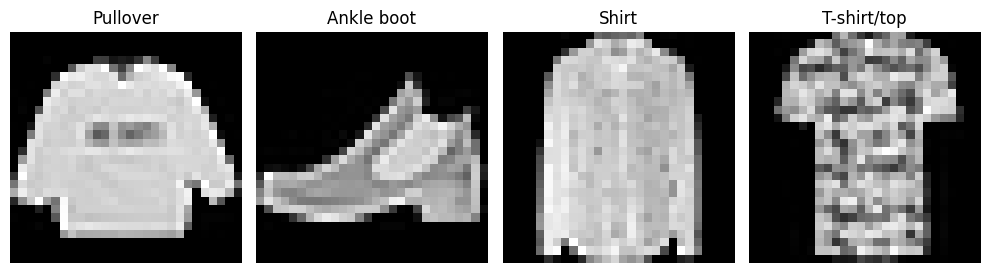

In [36]:
labels = y_train.values
images = x_train.values  # 픽셀 값만 가져옵니다

# 첫 4개의 이미지와 레이블 가져오기
num_images_to_show = 4
images_to_show = images[:num_images_to_show]
labels_to_show = labels[:num_images_to_show]

# 각 클래스의 이름
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
# 이미지 출력
plt.figure(figsize=(10, 4))
for i in range(num_images_to_show):
    img = images_to_show[i].reshape(28, 28)
    label = class_names[labels_to_show[i]]
    plt.subplot(1, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
x_train = x_train.values
y_train = y_train.values

x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.2, random_state=24)

print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(48000, 784)
(12000, 784)
(48000,)
(12000,)


In [38]:
# 데이터 셋 형태 변환 및 차원 확인 
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_valid = x_valid.reshape(x_valid.shape[0], 28, 28, 1)

print(x_train.shape)
print(x_valid.shape)

(48000, 28, 28, 1)
(12000, 28, 28, 1)


In [39]:
#이미지 데이터의 차원 순서 변경 
x_train = x_train.transpose(0, 3, 1, 2)
x_valid = x_valid.transpose(0, 3, 1, 2)

print(x_train.shape)
print(x_valid.shape)
#pytorch는 이미지 데이터를 ( 배치 크기, 채널, 높이, 너비 ) 순서로 기대 
# tensorflow및 keras는 ( 배치 크기, 높이, 너비, 채널 ) 순서로 기대
# example) (4000, 1, 28, 28)
# 4000은 smmple의 수, 1은 채널 수(그레이스케일 이미지), 28은 높이, 28은 너비

(48000, 1, 28, 28)
(12000, 1, 28, 28)


In [40]:
x_train = torch.tensor(x_train, dtype=torch.float32) / 255.0
y_train = torch.tensor(y_train, dtype=torch.long)
x_valid = torch.tensor(x_valid, dtype=torch.float32) / 255.0
y_valid = torch.tensor(y_valid, dtype=torch.long)
#numpy array는 데이터를 효율적으로 저장하고, 배열 연산을 빠르게 수행할 수 있다. 
#Tensorflow, torch는 numpy array를 기반으로 만들어졌기 때문에, numpy array를 tensor로 변환하여 모델 학습에 사용할 수 있다.

# 왜 float32로 변환했는가?

## 메모리 효율성 

- float32는 float64 보다 메모리를 절반만 사용, 따라서 대규모 데이터 셋을 처리할 때 메모리 사용량을 줄일 수 있다. 

## 계산 효율성 

- 많은 하드웨어 가속기(GPU, TPU)는 float32연산을 최적화하고 있다. float32타입을 사용하면 계산 속도를 높일 수 있다. 

## 표준화 

- 딥러닝 모델 학습 시, float32 타입은 일반적으로 충분한 정밀도를 제공, 오버플로우 및 언더플로우 문제를 줄이는데 도움이 된다. 

# 왜 long 으로 ?

## 정수형 레이블 처리 

- y_train과 y_valid는 클래스 레이블을 나타내며, 이는 정수형 데이터, pytorch에서는 클래스 레이블을 나타낼 때 일반적으로 torch.long을 사용

## 손실 함수 호환성

- `CrossEntropyLoss`와 같은 손실 함수는 레이블을 long 타입으로 기대한다. 따라서 레이블 데이터를 torch.long 타입으로 변환해야 손실 함수와 호환

In [41]:
#CustomDataset class 
# pytorch의 Dataset클래스를 상속하여 구현된 사용자 정의 데이터 셋 
# 주로 데이터 셋을 다룰때 사용됨. 
# 이미지와 레이블을 관리하고, 배치 단위로 데이터를 모델에 공급할 수 있다. 
# 이미지에 대한 전처리나 데이터 증강을 transform을 통해 쉽게 적용할 수 있다. 
# Pytorch의 DataLoader와 함께 사용되어 모델 학습에 필요한 데이터를 효율적으로 제공할 수 있다. 
class CustomDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images #이미지 데이터의 배열 
        self.labels = labels #레이블 데이터의 배열, 기본값은 None으로 설정됨.
        self.transform = transform #이미지에 적용할 변환 함수(또는 함수 조합), 기본값은 None

    #주어진 인덱스 idx에 해당하는 데이터를 반환
    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform:
            image = self.transform(image)
        if self.labels is not None:
            label = self.labels[idx]
            return image, label
        else:
            return image

    def __len__(self):
        return len(self.images)

In [42]:
transform = transforms.Compose([
    transforms.Normalize((0.5,), (0.5,))
])
#1. transform.compose : 여러 전처리 작업을 순차적으로 적용할 수 있도록 하는 클래스 
#                       리스트 내에 정의된 전처리 작업들이 순서대로 적용됨. 
#2. transform.Normalize : 이미지 데이터를 정규화 하는 전처리 작업 
#                         첫번째 인자 (0.5,)는 채널별 평균값, 두번째 인자는 (0.5,) 채널별 표준 편차 
#                         모든 픽셀 값이 0.5를 중심으로 0.5의 표준편차를 가지도록 정규화. 
#                         이는 입력 이미지의 각 픽셀 값이 [-1, 1] 범위에 있도록 변경 
# Normalize((mean,), (std,)) -> 데이터셋 평균/표준편차 기준 Z-score 표준화
train_dataset = CustomDataset(x_train, y_train, transform=transform)
valid_dataset = CustomDataset(x_valid, y_valid, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=True)

In [43]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 7 * 7, 128) #fully connected layer
        self.fc2 = nn.Linear(128, 10) #fully connected layer

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) #첫번째, convolution layer
        x = self.pool(F.relu(self.conv2(x))) #두번째, convolution layer
        x = x.view(-1, 64 * 7 * 7) #flatten(x,start_dim=1) #flatten, -1 is auto setting batch size
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

코드의 완전 연결층(Fully Connected Layer) 입력 크기가 `64 * 7 * 7`로 설정된 것을 역추적해 보면, **이 모델에 들어오는 원본 이미지의 크기는 28x28 픽셀**임을 알 수 있습니다.

배치 크기(Batch Size)를 $N$이라고 가정할 때, 데이터(`x`)가 `forward` 함수를 통과하면서 배열(Tensor)의 형태가 어떻게 변하는지 단계별로 명확하게 정리해 드리겠습니다.

---

### 📦 단계별 텐서(Tensor) 형태 변화 추적

입력 데이터 형태: `[N, 1, 28, 28]` (배치 크기, 채널 수, 세로, 가로)

| 단계 | 코드(forward) | 텐서 크기 변환 (Shape) | 변화의 이유 |
| --- | --- | --- | --- |
| **0. 입력** | `x` (28x28 흑백 이미지) | `[N, 1, 28, 28]` | 흑백이므로 채널이 1, 크기는 28x28 |
| **1. Conv1** | `self.conv1(x)` | `[N, 32, 28, 28]` | 필터 개수가 32개이므로 채널이 32로 증가. `padding=1` 덕분에 가로/세로 크기(28)는 유지됨. |
| **2. ReLU 1** | `F.relu(...)` | `[N, 32, 28, 28]` | 활성화 함수는 값만 비선형으로 바꿀 뿐 크기에는 영향을 주지 않음. |
| **3. Pool 1** | `self.pool(...)` | `[N, 32, 14, 14]` | `kernel=2`, `stride=2`이므로 가로/세로 크기가 정확히 절반(14)으로 축소됨. |
| **4. Conv2** | `self.conv2(x)` | `[N, 64, 14, 14]` | 필터 개수가 64개이므로 채널이 64로 증가. 역시 `padding=1`이므로 크기(14) 유지. |
| **5. ReLU 2** | `F.relu(...)` | `[N, 64, 14, 14]` | 크기 유지. |
| **6. Pool 2** | `self.pool(...)` | `[N, 64, 7, 7]` | 다시 한번 가로/세로 크기가 절반(7)으로 축소됨. (최종 특징 맵 완성) |
| **7. Flatten** | `x.view(-1, 64 * 7 * 7)` | `[N, 3136]` | 3D 형태의 특징 맵(64x7x7)을 1D 벡터로 쫙 펼침. ($64 \times 7 \times 7 = 3136$) |
| **8. FC 1** | `self.fc1(x)` | `[N, 128]` | 3136개의 입력을 받아 128개의 출력으로 줄임. |
| **9. ReLU 3** | `F.relu(...)` | `[N, 128]` | 크기 유지. |
| **10. FC 2** | `self.fc2(x)` | `[N, 10]` | 128개의 입력을 최종적으로 10개의 클래스(예: 숫자 0~9)에 대한 점수(Logit)로 출력함. |

---



In [44]:
device = torch.device('cpu')

In [45]:
#1. model: 학습할 신경망 모델
#2. criterion: 손실 함수 (ex) nn.CrossEntropyLoss )
#3. optimizer: 최적화 알고리즘 ( ex) torch.optim.Adam )
#4. train_loader: 학습 데이터셋의 DataLoader class 
#5. val_loader: 검증 데이터 셋의 DataLoader class
#6. num_epochs: 학습할 에포크(epoch) 수, 기본값은 2
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=2):
    for epoch in range(num_epochs):
        model.train() #모델을 학습모드로 설정 
        running_loss = 0.0 #현재 에포크 동안 누적된 손실
        correct_train = 0 #현재 에포크 동안 정확하게 예측된 샘플 수 
        #tqdm : 반복문의 상태 progress를 보여주는 함수 
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch'):
            images, labels = images.to(device), labels.to(device)
            #image와 label을 GPU또는 CPU로 이동 시킨다. 
            optimizer.zero_grad() #옵티마이저의 기울기를 초기화 
            outputs = model(images) #이미지를 모델에 입력하여 출력(예측값)을 계산
            loss = criterion(outputs, labels) #손실 함수를 계산
            loss.backward() #역전파를 수행하여 기울기를 계산
            optimizer.step() #옵티마이저를 사용하여 모델의 가중치를 업데이트 

            running_loss += loss.item() * images.size(0) #배치 손실을 누적
            _, preds = torch.max(outputs, 1) #각 샘플에 대해 가장 높은 확률을 가진 클래스 인덱스를 예측
            correct_train += (preds == labels).sum().item() #정확하게 예측된 샘플 수를 누적 
        #에포크 손실 및 정확도 계산
        epoch_loss = running_loss / len(train_loader.dataset) #에포크 동안 평균 손실 
        train_accuracy = correct_train / len(train_loader.dataset) #에포크 동안의 학습 정확도 
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

        model.eval() #모델을 평가 모드로 설정 
        val_loss = 0.0 #검증 데이터의 누적 손실
        correct_val = 0 #검증 데이터셋에 대한 정확하게 예측된 샘플 수 
        with torch.no_grad(): #검증시에는 기울기 계산 하지 않음 
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_accuracy = correct_val / len(val_loader.dataset)
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

In [47]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()# 다중 클래스 분류 문제에 적합한 손실 함수 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, optimizer, train_loader, valid_loader, num_epochs=2)

Epoch 1/2:   0%|          | 0/750 [00:00<?, ?batch/s]

Epoch 1/2: 100%|██████████| 750/750 [00:13<00:00, 57.34batch/s]


Epoch 1/2, Train Loss: 0.4570, Train Accuracy: 0.8341
Validation Loss: 0.3285, Validation Accuracy: 0.8845


Epoch 2/2: 100%|██████████| 750/750 [00:09<00:00, 82.75batch/s]


Epoch 2/2, Train Loss: 0.2917, Train Accuracy: 0.8951
Validation Loss: 0.2740, Validation Accuracy: 0.9017


In [51]:
#test 데이터 로드 및 데이터 로더 생성 
test_df = pd.read_csv('./temp/test.csv')
x_test = test_df.iloc[:, 1:].values #첫번째 열을 제외한 나머지 데이터를 x_test에 저장 
print(f"x_test.shape: {x_test.shape}") # (28000, 784)
x_test = x_test.reshape(x_test.shape[0],28,28,1).transpose(0, 3, 1, 2)
print(f"x_test.shape after reshape and transpose: {x_test.shape}") # (28000, 1, 28, 28)
x_test = torch.tensor(x_test, dtype=torch.float32)

test_dataset = CustomDataset(x_test, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

x_test.shape: (10000, 784)
x_test.shape after reshape and transpose: (10000, 1, 28, 28)


In [53]:
model.eval()
predictions = []

with torch.no_grad(): # 기울기 계산을 비활성화 
    for images in test_loader:
        images = images.to(device) #CPU, GPU, MPS 선택
        outputs = model(images) #model이미지를 입력하여 출력을 계산
        _, preds = torch.max(outputs, 1) #출력값 중 가장 높은 값을 가진 클래스 인덱스를 예측
        predictions.extend(preds.cpu().numpy()) #예측된 클래스 인덱스를 CPU로 이동시키고 numpy로 변환 후 , predictions리스트에 추가 
        
predictions[:10]

[np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(5),
 np.int64(3),
 np.int64(5),
 np.int64(9),
 np.int64(8),
 np.int64(6)]

In [54]:
submission = pd.read_csv('./temp/sample_submission.csv')

submission['label'] = predictions
submission.to_csv('./temp/submission.csv', index=False)